# <span style="color:#336699">Aprendizado Supervisionado - Árvore de Decisão</span>
<hr style="border:2px solid #0077b9;">

<br/>

<div style="text-align: center;font-size: 90%;">
    Autor: <br/>
    Flávio Belizário da Silva Mota <br/>
    <br/>
</div>
</div>
O objetivo desde notebook é apresentar o algoritmo Árvore de Decisão para as tarefas de classificação e regressão.

# Árvore de Decisão

O objetivo de uma Árvore de Decisão é criar um modelo de treinamento que possa prever uma classe ou valor aprendendo regras de decisão simples a partir de dados de treinamento. A ideia é dividir os dados aplicando uma série de perguntas. Vamos analisar um exemplo do dia a dia:


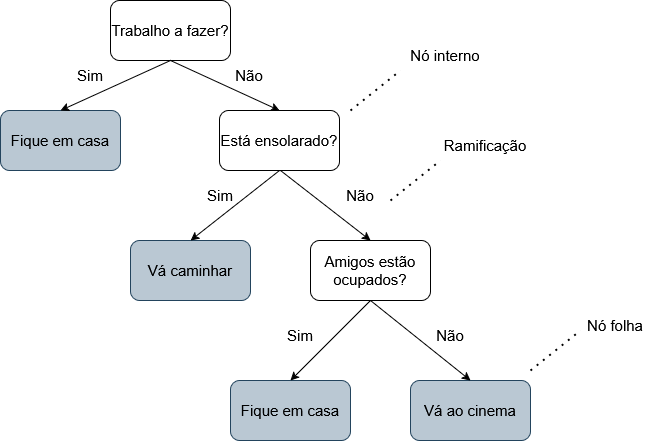

A Árvore de Decisão contém diferentes tipos de **nós e ramos**. Cada **nó interno** representa o **teste** e, com base no resultado do teste, formará outra **ramificação** ou um **nó folha**. Cada **ramificação** representa a **regra de decisão** e o **nó folha** representa o **resultado final**.

# Funcionamento interno da árvore de decisão
* No **nó raiz**, a Árvore de Decisão seleciona um atributo para dividir os dados em duas categorias principais.
* Os dados serão novamente divididos em duas categorias em cada subárvore.
* Este processo continuará até que todas as amostras de treinamento sejam classificadas.
* No final da Árvore de Decisão, terminamos com o **nó folha**, que representa a classe ou um valor contínuo que estamos tentando prever.

# Critérios para dividir os dados
O objetivo da Árvore de Decisão é dividir os dados de forma que, ao final, tenhamos diferentes grupos de dados com maior similaridade e menor aleatoriedade/impureza. Para atingir esse objetivo, cada divisão na Árvore de Decisão deve **reduzir a aleatoriedade**.

A Árvore de Decisão utiliza os critérios de seleção **entropia** ou **Gini** para dividir os dados.

## Entropia
Para encontrar o melhor atributo que reduzirá a aleatoriedade após uma divisão, podemos comparar a aleatoriedade antes e depois da divisão para cada atributo. No final, escolhemos o atributo que proporcionará a maior redução na aleatoriedade.

Formalmente, a aleatoriedade nos dados é conhecida como "Entropia", e a diferença entre a "Entropia" antes e depois da divisão é conhecida como **Ganho de Informação**. No caso de uma Árvore de Decisão, podemos ter múltiplos ramos, então a fórmula do ganho de informação pode ser escrita como:
```
    Ganho de informação = Entropia(nó de decisão pai) – (Entropia média(nós filhos))
```

A fórmula da entropia é dada por

$$
H(S) = - \sum_{i=1}^{n} p_i \log_{2}(p_i)
$$

onde:


*   $S$ é o conjunto de dados no nó
*   $p_i$ é a proporção de elementos da classe $i$ no conjunto
*   $n$ e o número de classes


Portanto, no caso da Entropia, a Árvore de Decisão dividirá os dados usando o atributo que fornece o **maior ganho de informação**.

## Gini
O índice de Gini é uma forma de medir a impureza de um nó em uma árvore de decisão e pode ser entendido como a probabilidade de que dois elementos escolhidos ao acaso pertençam a classes diferentes. Se todos os elementos de um nó pertencem à mesma classe, o índice de Gini será igual a zero, o que significa pureza total. Por outro lado, quanto mais misturadas estiverem as classes dentro do nó, maior será o valor de Gini, indicando maior incerteza.

Quando o algoritmo avalia uma possível divisão, ele calcula a impureza de Gini de cada subconjunto formado e tira uma média ponderada de acordo com o número de elementos de cada subconjunto. Esse valor mostra o quão boa foi a divisão: se a impureza resultante for menor, a divisão foi mais eficaz para separar as classes. O chamado ganho de Gini, ou redução de Gini, é a diferença entre a impureza antes da divisão e a impureza depois da divisão. Quanto maior for essa redução, melhor é a escolha do atributo para dividir os dados.

A fórmula do índice Gini é dada por

$$
Gini(S) = 1 - \sum_{i=1}^{n} p_i^2
$$

onde:

*   $S$ é o conjunto de dados no nó
*   $p_i$ é a proporção de elementos da classe $i$ no conjunto
*   $n$ e o número de classes

Portanto, no caso do Gini, a Árvore de Decisão dividirá os dados usando o atributo que fornece o maior ganho de Gini.

### Então, qual devemos usar?
O índice Gini é computacionalmente mais rápido, pois não requer o cálculo de funções logarítmicas, embora, na realidade, nenhuma das métricas resulte em uma árvore mais precisa que a outra.

# Vantagens da Árvore de Decisão
* Simples de entender e interpretar. As árvores podem ser visualizadas.
* Requer pouca preparação de dados. Outras técnicas frequentemente exigem a normalização dos dados e a remoção de valores em branco.
* Capaz de lidar com dados numéricos e categóricos.
* Utiliza um modelo de caixa branca. Os resultados são fáceis de interpretar.

# Desvantagens da Árvore de Decisão
* Os modelos podem gerar árvores excessivamente complexas que não generalizam bem os dados. Isso é chamado de sobreajuste. Mecanismos como poda, definição do número mínimo de amostras necessárias em um nó folha ou definição da profundidade máxima da árvore são necessários para evitar esse problema.
* Árvores de decisão podem ser instáveis, pois pequenas variações nos dados podem resultar na geração de uma árvore completamente diferente.
* Os modelos criam árvores tendenciosas se algumas classes dominarem. Portanto, recomenda-se balancear o conjunto de dados antes do ajuste com a árvore de decisão.

# Exemplo - Problema de classificação
Vamos usar o conjunto Iris para treinar uma Árvore de Decisão que classifique as plantas presentes no conjunto.

## Importar Bibliotecas
* numpy: Numpy é a biblioteca central para computação científica em Python. Ela é usada para trabalhar com arrays e matrizes.
* datasets: usaremos o conjunto de dados "iris"
* model_selection: usaremos model_selection.train_test_split() para dividir os dados
* tree: usaremos o classificador e o regressor da árvore de decisão
* graphviz: Usado para exportar a árvore para o formato Graphviz usando o exportador export_graphviz

In [ ]:
import numpy as np
from sklearn import datasets
from sklearn import model_selection
from sklearn import tree
import graphviz

## Carregando os dados

In [ ]:
# Carregando o conjunto de dados Iris
iris = datasets.load_iris()
X = iris.data  # Características
y = iris.target # Rótulos (classes)

### Criar conjunto de dados para teste e treinamento
* Dividiremos o conjunto de dados para que possamos usar um conjunto de dados para treinar o modelo e outro para testá-lo.
* Manteremos 20% dos dados para teste e 80% para treinar o modelo.

In [ ]:
X_train,X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size= 0.2, random_state= 50)
print('X_train= ', X_train.shape)
print('X_test= ', X_test.shape)
print('y_train= ', y_train.shape)
print('y_test= ', y_test.shape)

X_train=  (120, 4)
X_test=  (30, 4)
y_train=  (120,)
y_test=  (30,)


Agora vamos treinar o modelo usando a Árvore de Decisão

In [ ]:
dt = tree.DecisionTreeClassifier(random_state=42, max_depth=3)
dt.fit(X_train ,y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

### Testando o Modelo
* Para o teste, usaremos apenas os dados de teste

In [ ]:
# Fazendo previsões no conjunto de teste
y_pred = dt.predict(X_test)

### Avaliação do Modelo
Vamos medir a acurácia do modelo:

In [ ]:
from sklearn.metrics import accuracy_score
# Mostrar a precisão do modelo
print(f"A precisão do modelo no conjunto de teste é: {accuracy_score(y_test, y_pred):.2f}")

A precisão do modelo no conjunto de teste é: 0.97


## Visualização da Árvore de Decisão
Usaremos a função plot_tree() do sklearn para plotar a árvore e, em seguida, exportá-la no formato Graphviz usando o exportador export_graphviz. Os resultados serão salvos no arquivo iris_decision_tree.pdf.

[Text(0.375, 0.875, 'x[2] <= 2.45\ngini = 0.666\nsamples = 120\nvalue = [41, 38, 41]'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 41\nvalue = [41, 0, 0]'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[3] <= 1.65\ngini = 0.499\nsamples = 79\nvalue = [0, 38, 41]'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'x[2] <= 4.95\ngini = 0.176\nsamples = 41\nvalue = [0, 37, 4]'),
 Text(0.125, 0.125, 'gini = 0.0\nsamples = 36\nvalue = [0, 36, 0]'),
 Text(0.375, 0.125, 'gini = 0.32\nsamples = 5\nvalue = [0, 1, 4]'),
 Text(0.75, 0.375, 'x[2] <= 4.85\ngini = 0.051\nsamples = 38\nvalue = [0, 1, 37]'),
 Text(0.625, 0.125, 'gini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.875, 0.125, 'gini = 0.0\nsamples = 34\nvalue = [0, 0, 34]')]

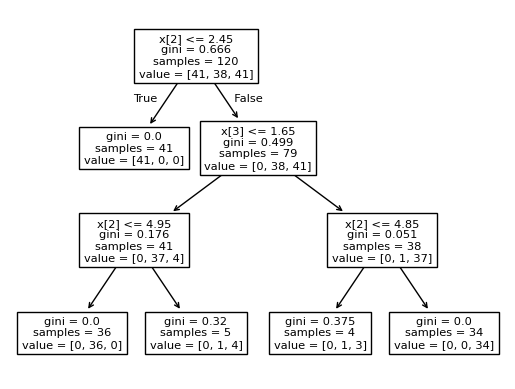

In [ ]:
tree.plot_tree(dt)

In [ ]:
dot_data = tree.export_graphviz(dt, out_file=None)
graph = graphviz.Source(dot_data)
graph.render("iris_decision_tree")

'iris_decision_tree.pdf'

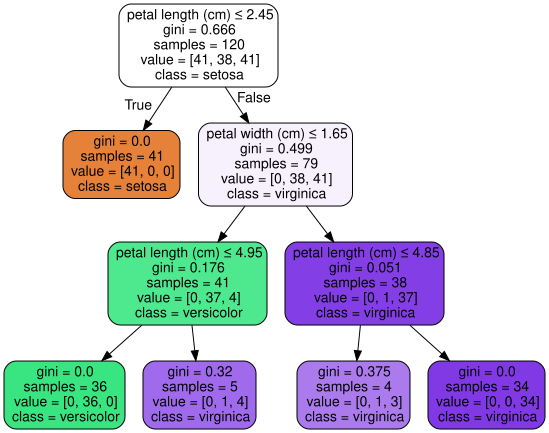

In [ ]:
dot_data = tree.export_graphviz(dt, out_file=None,
                      feature_names=iris.feature_names,
                      class_names=iris.target_names,
                      filled=True, rounded=True,
                      special_characters=True)
graph = graphviz.Source(dot_data)
graph

# Atividade
Utilize agora o conjunto de dados de reconhecimento de vinhos ([Wine recognition dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#wine-recognition-dataset)) da scikit para treinar uma Árvore de Decisão. Exiba a árvore gerada. Avalie o modelo usando as métricas que foram vistas na aula anterior.

In [ ]:
import numpy as np
from sklearn import datasets
from sklearn import model_selection
from sklearn import tree
import graphviz

In [ ]:
wine = datasets.load_wine()
X = wine.data  # Características
y = wine.target # Rótulos (classes)

In [ ]:
X_wine,X_wine, y_wine, y_wine = model_selection.train_test_split(X, y, test_size= 0.2, random_state= 50)
print('X_train= ', X_wine.shape)
print('X_test= ', X_wine.shape)
print('y_train= ', y_wine.shape)
print('y_test= ', y_wine.shape)

X_train=  (36, 13)
X_test=  (36, 13)
y_train=  (36,)
y_test=  (36,)


In [ ]:
dt = tree.DecisionTreeClassifier(random_state=42, max_depth=4)
dt.fit(X_wine ,y_wine)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
# Fazendo previsões no conjunto de teste
y_pred = dt.predict(X_wine)

In [ ]:
y_pred

array([1, 1, 1, 2, 2, 2, 1, 1, 0, 2, 0, 0, 1, 0, 1, 2, 1, 2, 1, 0, 0, 1,
       0, 2, 0, 0, 1, 1, 0, 1, 0, 0, 2, 2, 0, 1])

A precisão do modelo no conjunto de teste é: 1.00


[Text(0.4444444444444444, 0.875, 'x[0] <= 12.795\ngini = 0.656\nsamples = 36\nvalue = [13, 14, 9]'),
 Text(0.2222222222222222, 0.625, 'x[7] <= 0.605\ngini = 0.133\nsamples = 14\nvalue = [0, 13, 1]'),
 Text(0.3333333333333333, 0.75, 'True  '),
 Text(0.1111111111111111, 0.375, 'gini = 0.0\nsamples = 13\nvalue = [0, 13, 0]'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6666666666666666, 0.625, 'x[6] <= 1.735\ngini = 0.517\nsamples = 22\nvalue = [13, 1, 8]'),
 Text(0.5555555555555556, 0.75, '  False'),
 Text(0.5555555555555556, 0.375, 'gini = 0.0\nsamples = 8\nvalue = [0, 0, 8]'),
 Text(0.7777777777777778, 0.375, 'x[5] <= 3.225\ngini = 0.133\nsamples = 14\nvalue = [13, 1, 0]'),
 Text(0.6666666666666666, 0.125, 'gini = 0.0\nsamples = 13\nvalue = [13, 0, 0]'),
 Text(0.8888888888888888, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]')]

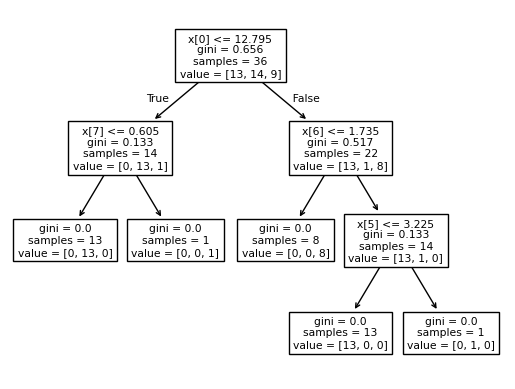

In [ ]:
from sklearn.metrics import accuracy_score
# Mostrar a precisão do modelo
print(f"A precisão do modelo no conjunto de teste é: {accuracy_score(y_wine, y_pred):.2f}")
tree.plot_tree(dt)

In [ ]:
dot_data = tree.export_graphviz(dt, out_file=None)
graph = graphviz.Source(dot_data)
graph.render("wine_decision_tree")

'wine_decision_tree.pdf'

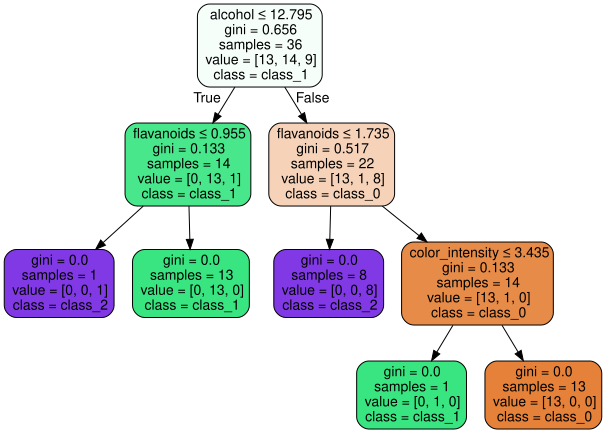

In [ ]:
dot_data = tree.export_graphviz(dt, out_file=None,
                      feature_names=wine.feature_names,
                      class_names=wine.target_names,
                      filled=True, rounded=True,
                      special_characters=True)
graph = graphviz.Source(dot_data)
graph

# Exemplo - Problema de regressão

Para resolver o problema de regressão com a Árvore de Decisão, vamos utilizar o dataset **California Housing**.

Este conjunto de dados foi derivado do censo americano de 1990, utilizando uma linha por grupo de quarteirões censitários. Um grupo de quarteirões é a menor unidade geográfica para a qual o Departamento do Censo dos EUA publica dados amostrais (um grupo de quarteirões normalmente tem uma população de 600 a 3.000 pessoas).

Um domicílio é um grupo de pessoas que residem em uma casa. Como o número médio de cômodos e quartos neste conjunto de dados é fornecido por domicílio, essas colunas podem assumir valores surpreendentemente altos para grupos de quarteirões com poucas famílias e muitas casas vazias, como resorts de férias.

O alvo que queremos encontrar é o valor médio das casas nos distritos da Califórnia, expresso em centenas de milhares de dólares (US$ 100.000).

Os atributos são:

*  MedInc: mediana da renda
*  HouseAge: mediana da idade da casa
*  AveRooms: número médio de cômodos por domicílio
*  AveBedrms: número médio de quartos por domicílio
*  Population: população dos quarteirões
*  AveOccup: número médio de membros do domicílio
*  Latitude: do grupo de quarteirões
*  Longitude: do grupo de quarteirões

In [ ]:
housing = datasets.fetch_california_housing()
X = housing.data # Atributos
y = housing.target # Valores alvo

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Vamos ver o dataset em um DataFrame pandas
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
housing_df['target'] = housing.target
display(housing_df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


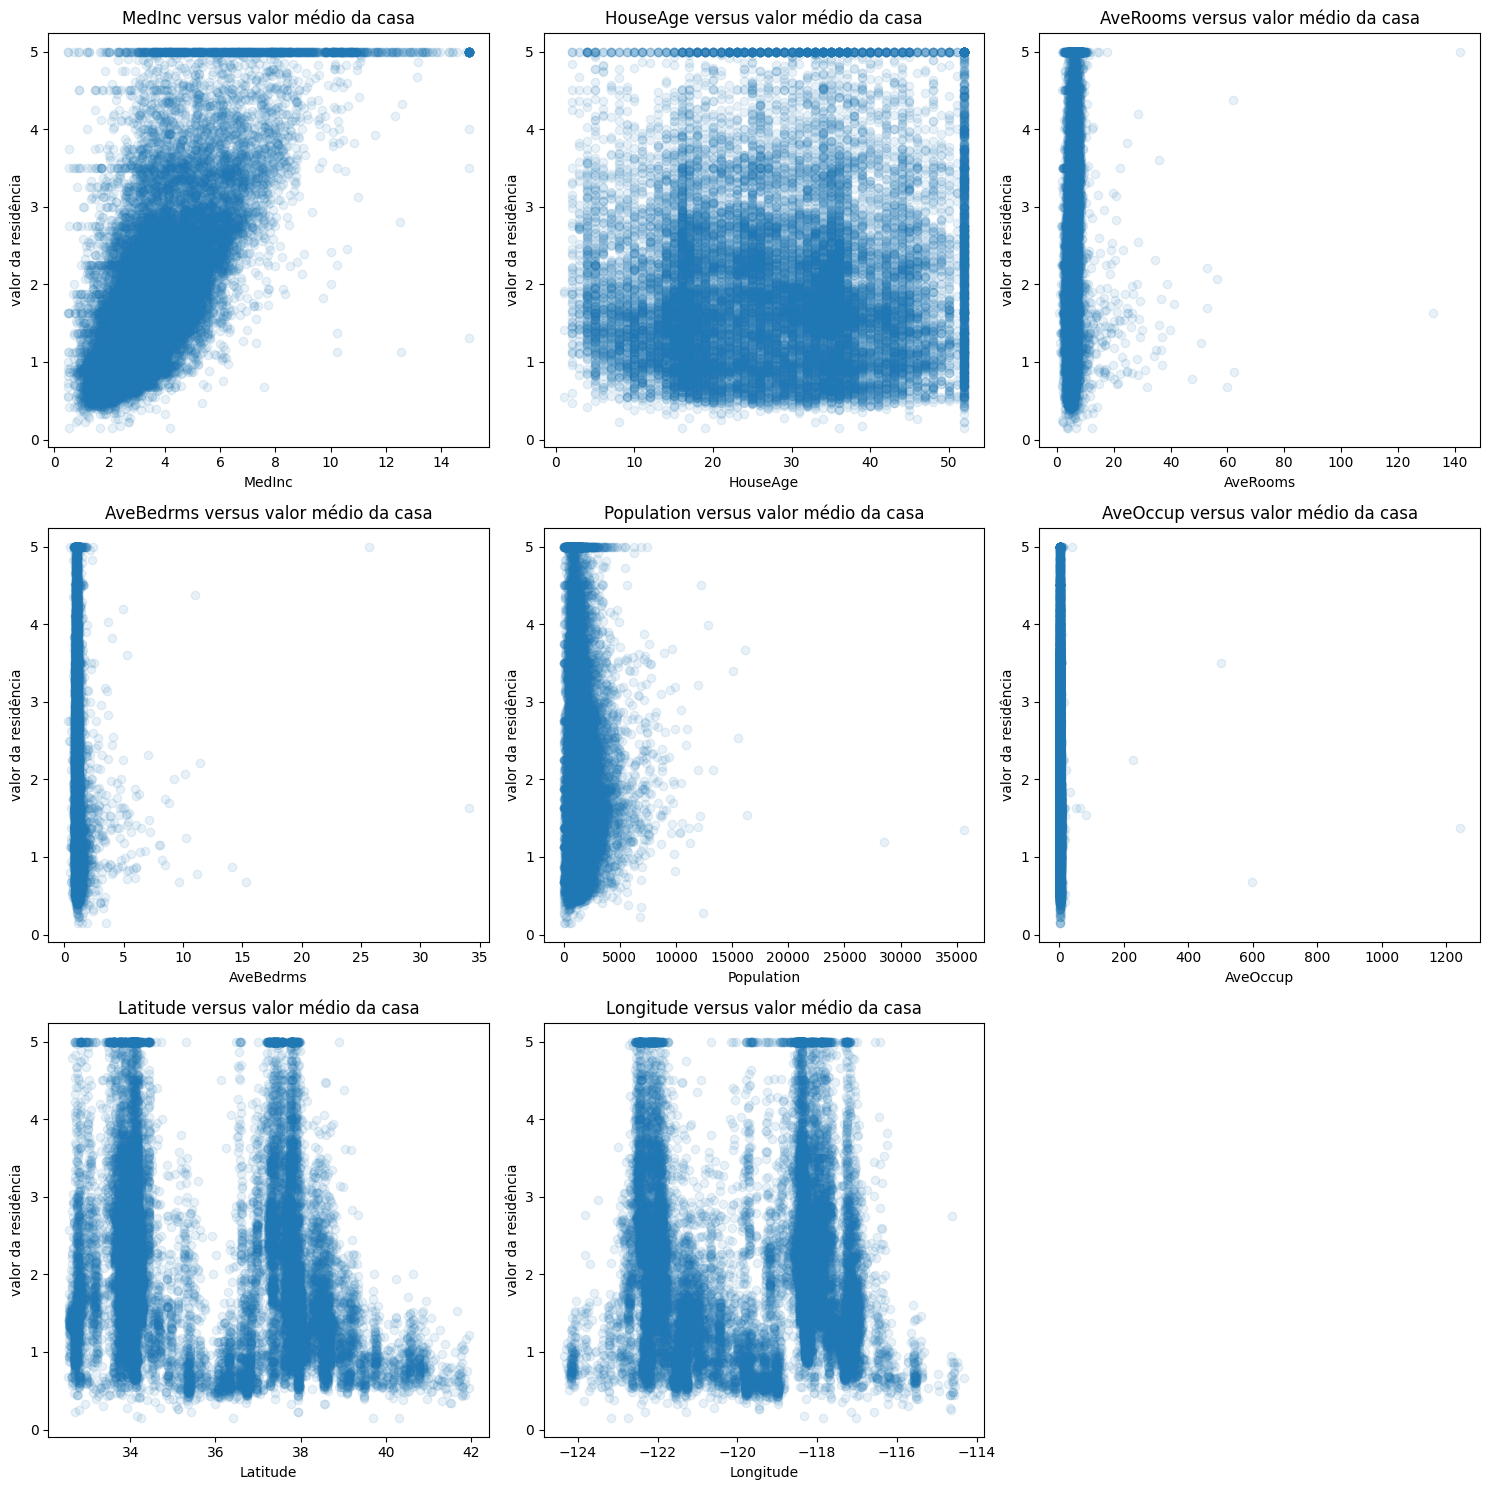

In [ ]:
# Vamos criar gráficos de dispersão de cada atributo versus valor médio da casa
n_features = len(housing.feature_names)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(housing.feature_names):
    axes[i].scatter(housing_df[col], housing_df['target'], alpha=0.1)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('valor da residência')
    axes[i].set_title(f'{col} versus valor médio da casa')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
X_train,X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size= 0.2, random_state= 42)
print('X_train= ', X_train.shape)
print('X_test= ', X_test.shape)
print('y_train= ', y_train.shape)
print('y_test= ', y_test.shape)

X_train=  (16512, 8)
X_test=  (4128, 8)
y_train=  (16512,)
y_test=  (4128,)


### Árvores de decisão para regressão

As árvores de decisão são modelos de aprendizado de máquina que dividem o espaço dos dados em regiões cada vez menores, tomando decisões em cada "nó" da árvore. No caso da** regressão**, o objetivo não é classificar em categorias, mas **prever um valor numérico contínuo**.

Cada divisão é feita em função da** variável independente** que melhor reduz a variabilidade do alvo dentro de cada subconjunto. Ao final, cada "folha" da árvore contém um **valor médio do alvo para os exemplos que chegaram até ela**.

### Como a Árvore Faz as Divisões?

O algoritmo analisa todos os atributos disponíveis e busca o ponto de corte que mais reduz o erro de previsão dentro de cada grupo.
Na regressão, esse erro costuma ser medido pelo erro quadrático médio (MSE - Mean Squared Error).

O processo segue assim:

1.  Escolher a variável e o ponto de divisão que melhor reduzem o MSE.
2.  Dividir o conjunto de dados em dois subconjuntos.
3.  Repetir o processo recursivamente até atingir critérios de parada, como profundidade máxima ou número mínimo de amostras em cada nó.
4.  O valor previsto em cada folha é a média dos valores do alvo naquela região.


Imagine que você tem uma única variável independente (por exemplo, o tamanho de uma casa) e o valor alvo é o preço.
A árvore tentará encontrar pontos de corte no tamanho que melhor separam casas baratas de caras, reduzindo a variabilidade dentro de cada grupo.
No fim, se uma nova casa tiver 100 m², a previsão será a média dos preços das casas que caíram na mesma folha.

In [ ]:
dt = tree.DecisionTreeRegressor(random_state=42, max_depth=6)
dt.fit(X_train ,y_train)

DecisionTreeRegressor(max_depth=6, random_state=42)

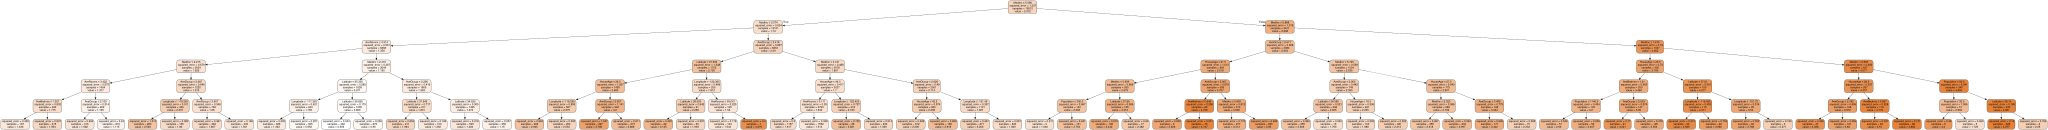

In [ ]:
dot_data = tree.export_graphviz(dt, out_file=None,
                      feature_names=housing.feature_names,
                      class_names=housing.target_names,
                      filled=True, rounded=True,
                      special_characters=True)
graph = graphviz.Source(dot_data)
graph

### Mas como medir o desempenho?

Para avaliar se a árvore está prevendo bem, usamos métricas de regressão. As mais comuns são:

**Erro Quadrático Médio (MSE):**

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$
Mede o erro ao quadrado, penalizando mais os grandes desvios.



**Raiz do Erro Quadrático Médio (RMSE):**

$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$
É o erro médio em unidades originais da variável, facilitando a interpretação.

**Erro Absoluto Médio (MAE):**
$$
MAE = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$
Mede o erro médio em termos absolutos, sem penalizar tanto os outliers.

**Coeficiente de Determinação (R²):**
$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$
Indica a proporção da variabilidade dos dados explicada pelo modelo. Valores próximos de 1 indicam boa previsão.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = dt.predict(X_test)
# MSE
mse = mean_squared_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mse)

# MAE
mae = mean_absolute_error(y_test, y_pred)

# R²
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

MSE: 0.4972838079675652
RMSE: 0.7051835278617654
MAE: 0.5008044131156354
R²: 0.6205125146233951


### O que isso significa?

**MSE (0.4973)**

O Erro Quadrático Médio indica a média dos erros ao quadrado entre os valores previstos e os reais. Como ele está em torno de 0.49, significa que, em média, o modelo erra aproximadamente meio ponto quadrado em relação à escala da variável dependente. Por ser ao quadrado, grandes erros pesam mais no cálculo.

**RMSE (0.7052)**

A raiz quadrada do MSE traz o erro para a mesma unidade da variável alvo. Aqui, temos um erro médio de 0.70. Isso significa que, em termos absolutos, o modelo se desvia em torno de 0.70 unidades do valor real do preço da casa (considerando o valor escalado, pois no California Housing normalmente se divide os preços médios por 100.000).

Se voltarmos à escala original (se o preço médio foi dividido por 100.000), isso significa que o erro médio é de aproximadamente 70.000 dólares.

**MAE (0.5008)**

O Erro Absoluto Médio mostra o erro médio sem penalizar tanto os outliers. Aqui, o valor de 0.50 indica que, em média, o modelo erra meio ponto em relação à escala original. Convertendo para o preço médio das casas (multiplicando por 100.000), o erro seria de 50.000 dólares por previsão.

Isso mostra que o modelo, apesar de razoável, ainda comete erros relevantes em termos financeiros.

**R² (0.6205)**

O coeficiente de determinação mede a proporção da variabilidade dos preços que é explicada pelo modelo. Um valor de 0.62 significa que aproximadamente 62% da variabilidade no preço das casas é explicada pelas variáveis do dataset (renda média, idade média dos imóveis etc.).

Em problemas de regressão em dados do mundo real, um R² em torno de 0.6 é considerado aceitável, pois mostra que o modelo capta uma boa parte do padrão, mas ainda há variabilidade que ele não consegue explicar — provavelmente por fatores não presentes no dataset (infraestrutura, mercado imobiliário, aspectos socioeconômicos locais).

In [ ]:
# Selecionando um único registro do conjunto de teste (por exemplo, o primeiro)
single_record_X = X_test[0].reshape(1, -1)
single_record_y = y_test[0]

# Fazendo a previsão para o registro selecionado
single_record_pred = dt.predict(single_record_X)

# Exibindo os resultados
print("Atributos do registro:")
for name, value in zip(housing.feature_names, single_record_X[0]):
    print(f"{name}: {value}")

print("\nValor real:", single_record_y)
print("Valor previsto:", single_record_pred[0])

Atributos do registro:
MedInc: 1.6812
HouseAge: 25.0
AveRooms: 4.192200557103064
AveBedrms: 1.0222841225626742
Population: 1392.0
AveOccup: 3.8774373259052926
Latitude: 36.06
Longitude: -119.01

Valor real: 0.477
Valor previsto: 1.1148088112745094


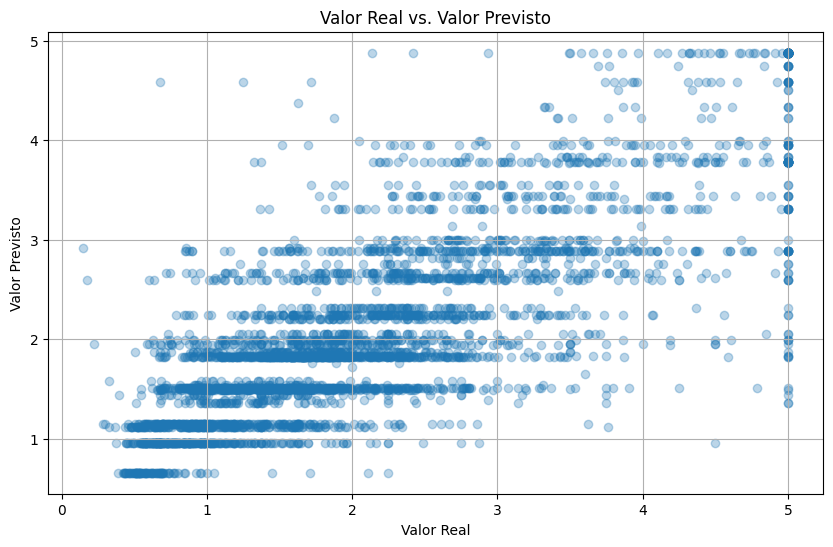

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Valor Real vs. Valor Previsto")
plt.grid(True)
plt.show()

## Atividade

Façam o treinamento da árvore de decisão para regressão alterando o parâmetro de profundidade e avalie o novo modelo.